In [42]:
import random
import torch
import numpy as np
import sklearn

"""FUNCTIONS TO CREATE THE CORPUS"""

PAIRS = [("(", ")"), ("[", "]")]

def generate_dyck(length: int, max_depth: int, k: int = 2) -> str | None:
    """Return a random Dyck string of exactly `length` tokens (even)
    with maximum nesting depth <= max_depth, or None on failure"""
    assert length % 2 == 0
    stack, result, depth = [], [], 0
    remaining = length

    for step in range(length):
        must_close = (len(stack) == remaining)
        can_open = (depth < max_depth) and (remaining > len(stack) + 1)

        choices = []
        if can_open and not must_close:
          choices.append("open")
        if stack:
          choices.append("close")

        if not choices:
          return None
        
        match random.choice(choices):
            case "open":
                pair = random.choice(PAIRS[:k])
                stack.append(pair)
                result.append(pair[0])
                depth += 1
            case "close":
                pair = stack.pop()
                result.append(pair[1])
                depth = len(stack)

    return "".join(result) if not stack else None

def generate_sequences(num_sequences, min_token, max_token, depths : list):
    sequences = []
    while len(sequences) != num_sequences:
        depth = random.choice(depths)
        num_tokens = random.randint(min_token, max_token)
        
        if num_tokens % 2 == 0:
            x = generate_dyck(num_tokens, depth)
            if x is not None:
                sequences.append(x)
        
    return sequences            

def e1(seq):
    closing_brackets = [PAIRS[i][1] for i in range(len(PAIRS))]
    current_id = random.randint(0,len(seq)-1)
    while seq[current_id] not in closing_brackets:
        current_id = random.randint(0,len(seq)-1)
    return seq[:current_id] + seq[current_id+1:]

def e2(seq):
    opening_brackets = [PAIRS[i][0] for i in range(len(PAIRS))]
    bracket = random.choice(opening_brackets)
    id = random.randint(0, len(seq)-1)
    return seq[:id] + bracket + seq[id:]

def e3(seq):
    closing_brackets = [PAIRS[i][1] for i in range(len(PAIRS))]
    current_id = random.randint(0,len(seq)-1)
    while seq[current_id] not in closing_brackets:
        current_id = random.randint(0,len(seq)-1)
    closing_brackets.remove(seq[current_id])
    sub_bracket = random.choice(closing_brackets)
    return seq[:current_id] + sub_bracket + seq[current_id+1:]

def e4(seq):
    closing_brackets = [PAIRS[i][1] for i in range(len(PAIRS))]
    return random.choice(closing_brackets) + seq

def create_examples(sequences, balanced : bool):
    if balanced==True:
        half = len(sequences)//2
        examples = []
        keep_trace = {}
        modified_ids = []
        for _ in range(half):
            id = random.randint(0, len(sequences)-1)
            error = random.randint(1, 4)
         
            if error == 1:
                seq = e1(sequences[id])
                examples.append((seq, torch.tensor([0])))
                keep_trace.update({seq : f'ERROR{1}'})
            elif error == 2:
                seq = e2(sequences[id])
                examples.append((seq, torch.tensor([0]))) 
                keep_trace.update({seq : f'ERROR{2}'})              
            elif error == 3:
                seq = e3(sequences[id])
                examples.append((seq, torch.tensor([0]))) 
                keep_trace.update({seq : f'ERROR{3}'})  
            elif error == 4:
                seq = e4(sequences[id])
                examples.append((seq, torch.tensor([0]))) 
                keep_trace.update({seq : f'ERROR{4}'})
                
           
            modified_ids.append(id)
        
        for id in range(len(sequences)):
            if id not in modified_ids:
                examples.append((sequences[id], torch.tensor([1])))
    else: 
        num_wrong_examples = random.randint(0, len(sequences))
        examples = []
        keep_trace={}
        modified_ids = []
        for _ in range(num_wrong_examples):
           
            id = random.randint(0, len(sequences)-1)
            error = random.randint(1, 4)
                      
            if error == 1:
                seq = e1(sequences[id])
                examples.append((seq, torch.tensor([0])))
                keep_trace.update({seq : f'ERROR{1}'})
            
            elif error == 2:
                seq = e2(sequences[id])
                examples.append((seq, torch.tensor([0]))) 
                keep_trace.update({seq : f'ERROR{2}'})            
            
            elif error == 3:
                seq = e3(sequences[id])         
                examples.append((seq, torch.tensor([0]))) 
                keep_trace.update({seq : f'ERROR{3}'}) 
            
            elif error == 4:
                seq = e4(sequences[id])
                examples.append((seq, torch.tensor([0]))) 
                keep_trace.update({seq : f'ERROR{4}'})
                
        for id in range(len(sequences)):
            if id not in modified_ids:
                examples.append((sequences[id], torch.tensor([1])))
        
    return examples, keep_trace



In [2]:
""" TESTS / FUNCTIONS TO CREATE THE CORPUS """

seq = generate_sequences(20, 4, 40, [0, 1, 2, 3, 4])
print(seq)
print(f'length of sequence : {len(seq)}')
print(create_examples(seq, True))

print(seq[-1])

A = torch.tensor([0, 1, 2, 3, 4])
B = torch.tensor([0, 1, 3, 3, 1])
C = (A==B)
print(C)
print(A[C])


['[]([][])[]([])[[]]', '[][[]([]())](([()[][][]()][[]()]))()', '[[]](())[]()()[][[]][]()()[][]()[](())', '()[()][]()[()[]()[][]](())()', '[][][]()()()()()', '()[][]()((())[])', '[[[]]][[](())()(()[])()][]((()())(())[])', '()[][][][]()()()()[]', '[()]', '[(())()()][]', '()[]', '[][]()()', '[][]()[]', '()[()]()(())[][][]()[]()[][()]', '([])[]([]())(())()[[]][[]]([])[()]', '()()()()[][][]()()()[]()()[][]()[]()[][]', '()[][][]()[][]()()()[]()[]()()', '()[][][[]]()()[]([])', '[][][]()()()()[]()[]()()()()[]', '[]()']
length of sequence : 20
([('()[][][]()[][)()()()[]()[]()()', tensor([0])), (')()[][][[]]()()[]([])', tensor([0])), ('()[][]()((()[])', tensor([0])), (']()[][][][]()()()()[]', tensor([0])), (']()[()]()(())[][][]()[]()[][()]', tensor([0])), ('()[][][]()[][](()()[]()[]()()', tensor([0])), ('()[(]()(())[][][]()[]()[][()]', tensor([0])), ('()[][][][]()()()()[[]', tensor([0])), ('[]([][])[]([])[[]', tensor([0])), ('[][][]()()()()[()[]()()()()[]', tensor([0])), ('[][[]([]())](([()[][][

In [37]:
""" GET THE CORPUS """

# Get sets of examples for each split 
train_examples, train_error_types = create_examples(generate_sequences(50000, 4, 40, depths=[0, 1, 2, 3, 4]), True)
dev_examples, dev_error_types = create_examples(generate_sequences(5000, 4, 40, depths=[0, 1, 2, 3, 4]), True)
indist_examples, indist_error_types = create_examples(generate_sequences(5000, 4, 40, depths=[0, 1, 2, 3, 4]), True)
OOD_examples, OOD_error_types = create_examples(generate_sequences(5000, 40, 80, depths=[5, 6, 7]), False)
print(f'training examples : {train_examples[:10]}')
print(train_error_types[f'{train_examples[0][0]}'])

training examples : [('()[]()[[][]([))[[]][()[]()]]', tensor([0])), ('([))', tensor([0])), (')()()()[][]()[]()()[][][][][]', tensor([0])), ('([])([]()[)[[]](())', tensor([0])), ('[](([)()))()[[()[]]]', tensor([0])), ('((())[([[]()()])](())(()[[[]]][([])])[]', tensor([0])), ('()()[][]()()()[][]()[](()()()()()()', tensor([0])), ('()[]([)()[]()', tensor([0])), ('()()()[]()()[]()()[][][]()[][)()()()', tensor([0])), ('()([])(())(()[]())[][[[]()]', tensor([0]))]
ERROR3


In [1]:
""" TOKENIZATION, GET_BATCH FUNCTION"""


vocabulary = {'[PAD]': 0, ')': 1, '[': 2, ']': 3, '(': 4, '[CLS]': 5, '[SEP]': 6} 
ids_to_tokens = {i:c for c, i in vocabulary.items()}


def get_tokens_id(sequence, max_len):
    tokens = []
# prepend [CLS] at the begining of each example   
    tokens.append(vocabulary['[CLS]'])
    for char in sequence:
        tokens.append(vocabulary[char])
# Pad tokens ids
    pad_len = max_len - len(sequence) -1  # -1 being for the [CLS] already added in tokens
    tokens += [vocabulary['[PAD]']]*pad_len
# replacing the last token id by a [SEP]
    tokens[-1] = vocabulary['[SEP]']
    return torch.tensor(tokens)

def convert_ids_to_tokens(example : torch.tensor):
    # remove [PAD], [CLS] and [SEP] tokens (due to our construction of the corpus)
    remove_pad = 0 < example   #we create a mask that will select only elements that are not equal to 0, 5 and 6 i.e. PAD, CLS and SEP
    without_pad = example[remove_pad]
    remove_cls_sep = without_pad < 5
    proper = without_pad[remove_cls_sep].tolist()
    return "".join([ids_to_tokens[proper[i]] for i in range(len(proper))])  

def get_batch(examples, batch_size, index, max_len):
    batch = torch.zeros(1, max_len)
    labels = torch.zeros(1)
    for example in examples[index:index+batch_size]:
        batch = np.concatenate((batch, get_tokens_id(example[0], max_len).unsqueeze(0)), 0)
        labels = np.concatenate((labels, example[1]))
    return torch.from_numpy(batch[1:,]).long(), torch.from_numpy(labels[1:,]).long()

    



NameError: name 'torch' is not defined

In [5]:
""" TEST / TOKENIZATION, GET_BATCH FUNCTION"""


batch, labels = get_batch(train_examples[40000:40010], 5, 0, 80)
batch1, labels1 = get_batch(train_examples[:10], 5, 5, 80)

print(train_examples[40000:40010])
print(batch)
print(labels)

L = ["a", "c", "a", "b"]
print("".join(L))


A = torch.tensor([1, 2, 3, 4, 5])
B = torch.tensor([1, 2, 3, 4, 6])



print((A == torch.tensor([1]*len(A))).sum().item())
print(A.tolist())


[('[()()()][](())[]([])[][]([][])([][])', tensor([1])), ('()()([][][])', tensor([1])), ('[()]()()([][])()()([])()', tensor([1])), ('()(())', tensor([1])), ('()[]()()[]()[]()()()()()[][]()[]', tensor([1])), ('()[][]()[]()()()[]()()[][]()()', tensor([1])), ('[][[]()][[]()()]()[](())()[()][[]][][()]', tensor([1])), ('()[]()[]()()[]', tensor([1])), ('()()()[][]()()()()()[][][][]()()()()[][]', tensor([1])), ('[]()[][]()[]()[]()[][]', tensor([1]))]
tensor([[5, 2, 4, 1, 4, 1, 4, 1, 3, 2, 3, 4, 4, 1, 1, 2, 3, 4, 2, 3, 1, 2, 3, 2,
         3, 4, 2, 3, 2, 3, 1, 4, 2, 3, 2, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 6],
        [5, 4, 1, 4, 1, 4, 2, 3, 2, 3, 2, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 6],

In [6]:
""" THE MODEL """

from transformers import BertConfig, BertModel
import torch.nn as nn

config = BertConfig(
    vocab_size=7,           
    hidden_size=64,         
    num_hidden_layers=2,    
    num_attention_heads=4,
    intermediate_size=256,  
    max_position_embeddings=80,
    pad_token_id=0
)

VOCAB_SIZE=7
PAD_ID=0
D_MODEL=64
N_LAYERS=2
N_HEADS=4
D_FF=256
DROPOUT=0.1
MAX_LEN=80
DEVICE = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

class BertBinaryClassifier(nn.Module): # we have to add a binary classifier at the top of our Bert model
   
   def __init__(self, config):
      super().__init__()
      self.model = BertModel(config, add_pooling_layer=False)
      self.classifier = nn.Linear(config.hidden_size, 2)

   def forward(self, input_ids):
      attention_mask = (input_ids != self.model.config.pad_token_id).long().to(DEVICE)
      outputs = self.model(input_ids, attention_mask)
      cls_repr = outputs.last_hidden_state[:, 0, :]  # size (B, d_model)  
      return self.classifier(cls_repr)  # outputs (B, 2) where "2" is the classes dimension (0 or 1)
   

In [28]:
""" TESTS / THE MODEL"""

config = BertConfig(
    vocab_size=7,           # (, ), [, ], [PAD], [CLS], [SEP]
    hidden_size=64,         # d = 64–128 comme recommandé
    num_hidden_layers=2,    # 2–4 layers
    num_attention_heads=4,
    intermediate_size=256,  # 4d
    max_position_embeddings=80,
    pad_token_id=0
)
print(config.pad_token_id)

string = "ERROR1"
if "1" in string:
    print("test")

0
test


In [39]:
""" FUNCTIONS TO TRAIN AND EVALUATE THE MODEL """

import math

MAX_LEN = 80
def evaluate(model, examples, criterion, batch_size):
    
    model.eval()
    total_loss = 0.0
    correct = 0   
    index = 0
    f_score = 0
    while index < len(examples) - batch_size :
        input_ids, labels = get_batch(examples, batch_size, index, MAX_LEN)
        
        logits = model(input_ids)
        
        loss = criterion(logits, labels)       
        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=1) 
           
        correct_pred = (predictions == labels).sum().item()
        correct += correct_pred

        f_score_batch = sklearn.metrics.f1_score(labels, predictions, average='macro')
        f_score += f_score_batch
        index+=batch_size
    """for example in examples:
        input_ids, labels = get_tokens_id(example[0], 80).unsqueeze(0).to(DEVICE), example[1].to(DEVICE)
        
        logits = model(input_ids)
        print(logits.size())
        print(labels.size())
        loss = criterion(logits, labels) 
        total_loss += loss.item()  """
    model.train()
    return {"accuracy" : correct / len(examples), 
            "F metrics" : f_score/(len(examples)/batch_size), 
            "dev loss" : total_loss/index }

     
def run_one_epoch(model, train_examples, dev_examples, batch_size, criterion, optimizer, scheduler=None):
    model.train()
    random.shuffle(train_examples)
    random.shuffle(dev_examples)
    metrics = {"training loss" : [], "evaluation metrics": None}
    metrics['evaluation metrics'] = evaluate(model, dev_examples, criterion, batch_size)
    index=0
    count = 0
    while index <= len(train_examples) - batch_size:
        if count % 5000 == 0:
            print("5000 steps done after last update")
        input_ids, labels = get_batch(train_examples, batch_size, index, MAX_LEN)
        input_ids.to(DEVICE)
        labels.to(DEVICE)
        optimizer.zero_grad()
        
        logits = model(input_ids)  # size (B, 2) for an instance of BertBinaryClassifier
        loss = criterion(logits, labels)
        metrics['training loss'].append(loss.item())
        
        loss.backward()
        
        optimizer.step()
        
        if scheduler is not None:
            scheduler.step()
        
        index += batch_size  
        count+=1     
    return metrics
    


def get_false_positives(model, examples, type_error : dict, batch_size):
    """return a list of false positives broken down by type"""
    model.eval()
    FP = []
    index = 0
    while index < len(examples) - batch_size:

        input_ids, labels = get_batch(examples, batch_size, index, MAX_LEN)
        logits = model(input_ids)
        predictions = torch.argmax(logits, -1)
        
    # First we get two boolean tensors 
        # One that gives us the uncorrect predicted labels (FP and FN)
        get_fp_fn = (predictions != labels)
       
        # One that gives us the positives predicted examples (TP and FP)
        get_positives = (predictions == torch.ones(len(predictions)))
        
        
        # Then we take the boolean operator "AND" between the two previous tensors
        get_fp = get_fp_fn*get_positives

        # get_fp is of size (B, ), thus we can select the examples in input_ids that are FP 
        fp = input_ids[get_fp,:]
        if fp.size(0) > 0:
            FP += [type_error[convert_ids_to_tokens(fp[i,:])] for i in range(fp.size(0))] # Thus FP will contain only examples that are mispredicted to be positive
                                                                                        # along with their error type
        
        index+=batch_size
    return FP
    

    

In [40]:
""" TRAINING ALGORITHM """



config = BertConfig(
    vocab_size=7,           
    hidden_size=64,        
    num_hidden_layers=2,    
    num_attention_heads=4,
    intermediate_size=256, 
    max_position_embeddings=80,
    pad_token_id=0
)
model = BertBinaryClassifier(config)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

"""TEST : for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)"""


EPOCHS = 10
BATCH_SIZE = 36

total_metrics = {}
for epoch in range(EPOCHS):
    metrics = run_one_epoch(model, train_examples, dev_examples, BATCH_SIZE, criterion, optimizer)    
    total_metrics[f"epoch n°{epoch}"] = metrics
    print(f"for epoch {epoch} : {metrics}")

print(total_metrics)







5000 steps done after last update
for epoch 0 : {'training loss': [0.7307628393173218, 0.7094020247459412, 0.6794682145118713, 0.7325693964958191, 0.7230849266052246, 0.8282584547996521, 0.7585409283638, 0.6882333159446716, 0.6820217370986938, 0.7790358662605286, 0.6986839175224304, 0.7066285610198975, 0.7151749134063721, 0.7394906878471375, 0.7405490875244141, 0.6939101815223694, 0.7029435634613037, 0.6603031158447266, 0.6998606324195862, 0.7156429886817932, 0.6823350787162781, 0.7145456075668335, 0.6607607007026672, 0.7432632446289062, 0.7113432288169861, 0.7175089716911316, 0.6722368597984314, 0.64775550365448, 0.6828418970108032, 0.6858303546905518, 0.6763683557510376, 0.6501088738441467, 0.6581257581710815, 0.7390604615211487, 0.7160965204238892, 0.6388590335845947, 0.7105901837348938, 0.6193602085113525, 0.6439303159713745, 0.6147148013114929, 0.6625120639801025, 0.6412928104400635, 0.6958836317062378, 0.6472532749176025, 0.6602882742881775, 0.562577486038208, 0.5790727734565735,

<class '__main__.BertBinaryClassifier'>


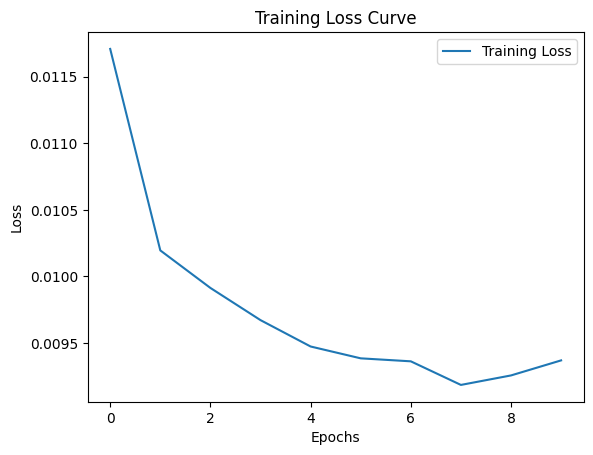

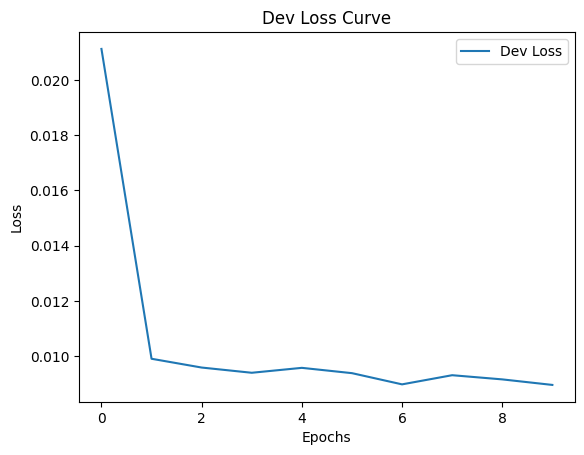

0.8728062239913154
0.8624119667998393
tensor([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1])
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True,  True, False, False, False, False,
        False, False, False, False,  True, False, False, False, False, False,
        False, False, False, False, False,  True])
tensor([False, False,  True, False, False, False, False,  True, False, False,
         True, False,  True, False,  True,  True,  True, False, False, False,
         True,  True,  True,  True,  True, False,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True])
tensor([[5, 4, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 

In [41]:
import matplotlib.pyplot as plt

train_losses = []
for epoch in range(EPOCHS):
    train_loss = total_metrics[f"epoch n°{epoch}"]["training loss"]
    avg_train_loss = sum(train_loss)/(len(train_examples) - BATCH_SIZE)
    train_losses.append(avg_train_loss)

dev_losses = []
for epoch in range(EPOCHS):
    dev_loss = total_metrics[f"epoch n°{epoch}"]['evaluation metrics']["dev loss"]
    dev_losses.append(dev_loss)


print(type(model))

plt.plot(train_losses, label="Training Loss")
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(dev_losses, label="Dev Loss")
plt.title('Dev Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

final_accuracy = total_metrics[f"epoch n°{epoch}"]["evaluation metrics"]["accuracy"]
final_F1 = total_metrics[f"epoch n°{epoch}"]["evaluation metrics"]["F metrics"]
print(final_accuracy)
print(final_F1)
fp = get_false_positives(model, dev_examples, dev_error_types, BATCH_SIZE )
print(fp)

e1 = 0
e2 = 0
e3 = 0
e4 = 0
for error in fp:
    if '1' in error:
        e1+=1
    if '2' in error:
        e2+=1
    if '3' in error:
        e3+=1
    if '4' in error:
        e4+=1

print(f'error 1 : {e1}')
print(f'error 2 : {e2}')
print(f'error 3 : {e3}')
print(f'error 4 : {e4}')
